In [1]:
# Transformers example -> Reverseing sequence of numbers


In [99]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer, LearnedPosEmbed, PosEmbed

from sbi.analysis import pairplot
import numpy as np

In [100]:
jax.devices()

[CpuDevice(id=0)]

In [101]:
ts = jnp.linspace(0, 3, 100)

def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey



In [104]:
num_timeponts = 18
ts_dense = jnp.linspace(0, 5, 100)
def generate_data(key, n):

    key1, key2, key3, key4, key5, key6 = jrandom.split(key, 6)

    theta1 = jax.nn.sigmoid(jrandom.normal(key1, (n,1)))*2 + 1.
    theta2 = jax.nn.sigmoid(jrandom.normal(key2, (n,1)))*2 + 1.
    theta3 = jax.nn.sigmoid(jrandom.normal(key3, (n,1)))*2 + 1.
    theta4 = jax.nn.sigmoid(jrandom.normal(key4, (n,1)))*2 + 1.
    
    # Random time points 
    ts = jrandom.uniform(key, (n , num_timeponts), minval=0, maxval=5)
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    predator = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, predator)
    prey = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts, ts_dense, prey)

    predator = predator + jrandom.normal(key5, predator.shape) * 0.0001
    prey = prey + jrandom.normal(key6, prey.shape) * 0.0001

    node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
    node_metadata = jnp.concatenate([jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),jnp.full((n, 1), jnp.nan),ts, ts], axis=1)
    full_data = jnp.concatenate([theta1, theta2, theta3, theta4, predator, prey], axis=1).reshape((n, -1, 1))
    return full_data, node_ids, node_metadata


data, node_ids, node_metadata = generate_data(jrandom.PRNGKey(1), 100)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

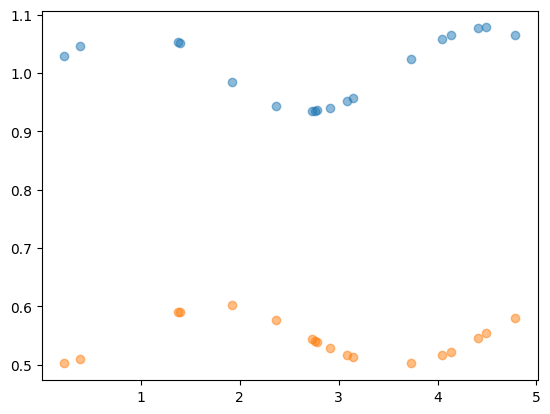

In [105]:
time_evals = node_metadata[:, 4:4+num_timeponts]
predator_trace = data[:, 4:4+num_timeponts]
prey_trace = data[:, 4+num_timeponts:]

for i in range(1):
    plt.scatter(time_evals[i], predator_trace[i], c='C0', alpha=0.5)
    plt.scatter(time_evals[i], prey_trace[i], c='C1', alpha=0.5)

In [106]:
key = jrandom.PRNGKey(0)

In [107]:
from probjax.nn.helpers import TimeEmbedding

In [131]:

def model(t, x, node_ids, node_metadata, condition_mask):
    condition_mask = condition_mask.astype(int)
    # Embed values and conditions

    dim = 30
    _dim = dim // 3
    embedding_net = hk.nets.MLP([dim, _dim])
    embedding_id_nets = hk.Embed(T_max, _dim)
    embedding_metadata = hk.nets.MLP([dim, _dim])
    embedding_time = hk.Sequential([TimeEmbedding(dim), hk.nets.MLP([dim, dim])])
    

    # Positional embedding

    model = Transformer(num_heads=1, num_layers=10, attn_size=dim, dropout_rate=0.0, widening_factor=2)

    # Embed values adn time
    value_embeddings = embedding_net(x)
    time_embeddings = embedding_time(t.reshape(-1,1,1))
    time_embeddings = jnp.broadcast_to(time_embeddings, value_embeddings.shape[:-1] + (dim,))

    # Embed node ids and metadata
    id_embeddings = embedding_id_nets(node_ids)
    metadata_embeddings = embedding_metadata(node_metadata.reshape(-1,T_max,1))
    metadata_embeddings = metadata_embeddings * ~jnp.isnan(metadata_embeddings)
    metadata_embeddings = jnp.broadcast_to(metadata_embeddings, value_embeddings.shape)
    id_embeddings = jnp.broadcast_to(id_embeddings, value_embeddings.shape)
    node_emebding = id_embeddings

    # Condition embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(dim,), init=hk.initializers.RandomNormal(stddev=0.1))
    condition_embedding = condition_embedding.reshape(1,1, -1) * condition_mask.reshape(-1, T_max,1)
    


    x_encoded = jnp.concatenate([value_embeddings, node_emebding, metadata_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding

    # Encode
    h = model(x_encoded)

    # Decode
    h_t = jnp.concatenate([time_embeddings, h], axis=-1)
    out = hk.nets.MLP([100, 100,100, 1])(h_t)

    out = out * (1-condition_mask.reshape(-1,len(node_ids),1))
    return out


In [132]:
init, model_fn = hk.transform(model)
params = init(key, jnp.ones(data.shape[0]), data, node_ids, node_metadata, jnp.zeros_like(node_ids))

In [133]:
times = jax.random.uniform(key, (data.shape[0], 1, 1), minval=1e-6, maxval=1.0)
out = model_fn(params, key, times, data, node_ids,node_metadata, jnp.zeros_like(node_ids))

In [134]:
T = 1.
T_min = 1e-6
beta_min = 0.1
beta_max = 10.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [135]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)


def loss_fn(params, key, batch_size= 32):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data
    times = jax.random.uniform(rng_time, (batch_size, 1, 1), minval=T_min, maxval=1.0)
    batch_xs, node_ids, node_metadata = generate_data(rng_data, batch_size) # n, T_max, 1

 
    # Condition mask -> randomly condition on some data -> Sample more frequently no condition
    #condition_mask = jax.random.choice(rng_condition, jnp.array([[0]*T_max, [1,0], [0,1]]), shape=(batch_size, ), p=jnp.array([1., 0.,0.]), axis=0)
    condition_mask = jnp.array([0]*T_max, dtype=int)
    condition_mask = condition_mask[..., None]


    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
    batch_noisy_xs = batch_noisy_xs * (1-condition_mask) + batch_xs * condition_mask # Condition on the data

    score_pred = model_fn(params, rng_model, times, batch_noisy_xs, node_ids,node_metadata, condition_mask[...,0])
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    # lam = beta(times) 
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times)
    # Loss

    loss = jnp.mean(jnp.sum((1- condition_mask)*lam*(score_pred - score_target) ** 2, axis=-2))
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [136]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [137]:
for j in range(10):
    l = 0
    for i in range(500):
        key = jrandom.PRNGKey(i + j * 20000)
        loss, params, opt_state = update(params, key, opt_state)
        l += loss / 500
    print(l)

11.355971
9.774561
9.637517
9.4189415
9.574911


Exception ignored in: <function _xla_gc_callback at 0x7f8e7c3a3760>
Traceback (most recent call last):
  File "/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/jax/_src/lib/__init__.py", line 98, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


In [126]:
from functools import partial

node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(jnp.linspace(0, 5, num_timeponts)) + list(jnp.linspace(0, 5, num_timeponts))) # Time points
condition_mask = jnp.array([0]*T_max, dtype=int)

def drift_backward(t, x, node_ids=node_ids, condition_mask=condition_mask, node_metadata=node_metadata):
    #t = T - t
    score = model_fn(params, key, t.reshape(-1, 1, 1), x.reshape(-1, len(node_ids), 1), node_ids,node_metadata, condition_mask[:len(node_ids)])
    score = score.reshape(x.shape)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f * (1-condition_mask)
    return f

def diffusion_backward(t,x, node_ids=node_ids,node_metadata=node_metadata,condition_mask=condition_mask):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b * (1-condition_mask[:len(node_ids)])
    return b

In [127]:
from probjax.utils.sdeint import sdeint

In [128]:

def sample_fn(key, shape, node_ids=node_ids, node_metadata=node_metadata, time_steps=200, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    condition_mask = condition_mask[:len(node_ids)]
    key1, key2 = jrandom.split(key, 2)
    x_T = jax.random.normal(key1, shape + (len(node_ids),)) * marginal_std(jnp.zeros(shape), 1.)
    x_T = x_T * (1-condition_mask) + condition_value * condition_mask
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, node_ids, condition_mask), lambda t, x: diffusion_backward(t, x, node_ids, condition_mask), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys[:, -1, :]

In [129]:

samples = sample_fn(jrandom.PRNGKey(0), (5, ))

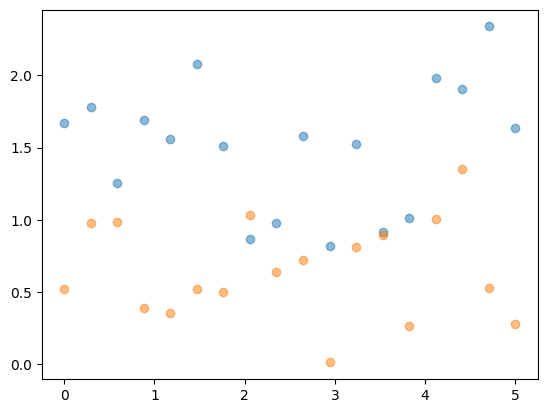

In [130]:
time_evals = node_metadata[4:4 + num_timeponts]
predator_trace = samples[:, 4:4 + num_timeponts]
prey_trace = samples[:, 4+num_timeponts:]

for i in range(1):
    plt.scatter(time_evals, predator_trace[i], c='C0', alpha=0.5)
    plt.scatter(time_evals, prey_trace[i], c='C1', alpha=0.5)